# Task 2: Grayscale Image Colorization using Convolutional Autoencoders

This notebook trains a convolutional autoencoder that maps grayscale inputs to RGB outputs. It also includes the bonus Adversarial Autoencoder (AAE) for RGB latent-space learning.


In [12]:
import math
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from skimage.metrics import structural_similarity
from sklearn.decomposition import PCA
from torch import nn
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

torch.set_num_threads(min(4, os.cpu_count() or 1))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FIGURES_DIR = Path("figures")
CHECKPOINTS_DIR = Path("checkpoints")
FIGURES_DIR.mkdir(exist_ok=True)
CHECKPOINTS_DIR.mkdir(exist_ok=True)

IMAGE_SIZE = 64
BATCH_SIZE = 32
AE_EPOCHS = 50
AE_LR = 1e-3
AE_PATIENCE = 10
AE_MIN_DELTA = 1e-4
AAE_EPOCHS = 50
AAE_LR = 1e-3
AAE_ADV_LR = 5e-4
LATENT_DIM = 64

RESAMPLE = Image.Resampling.BICUBIC if hasattr(Image, "Resampling") else Image.BICUBIC

print(f"Using device: {DEVICE}")
print(f"Colorization config: image_size={IMAGE_SIZE}, epochs={AE_EPOCHS}, batch_size={BATCH_SIZE}, lr={AE_LR}")
print(f"Early stopping: patience={AE_PATIENCE}, min_delta={AE_MIN_DELTA}")
print(f"AAE config: latent_dim={LATENT_DIM}, epochs={AAE_EPOCHS}, lr={AAE_LR}, adv_lr={AAE_ADV_LR}")


Using device: cpu
Colorization config: image_size=64, epochs=50, batch_size=32, lr=0.001
Early stopping: patience=10, min_delta=0.0001
AAE config: latent_dim=64, epochs=50, lr=0.001, adv_lr=0.0005


## Dataset Inspection and Split

The prompt names `data/AE DATA`, while this workspace contains `data/AE Data`. The resolver checks both. The dataset already contains the required train/test split, so the 10 test images are kept untouched.


In [13]:
def resolve_existing_path(candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    data_root = Path("data")
    if data_root.exists():
        lower_map = {p.name.lower(): p for p in data_root.iterdir() if p.is_dir()}
        for candidate in candidates:
            key = Path(candidate).name.lower()
            if key in lower_map:
                return lower_map[key]
    raise FileNotFoundError(f"None of these dataset paths exist: {candidates}")


def summarize_tree(root, max_files_per_dir=10):
    root = Path(root)
    print(f"Dataset root: {root.resolve()}")
    for directory in [root] + sorted([p for p in root.rglob("*") if p.is_dir()]):
        files = sorted([p.name for p in directory.iterdir() if p.is_file()])
        rel = directory.relative_to(root) if directory != root else Path(".")
        print(f"{rel}: {len(files)} files")
        for name in files[:max_files_per_dir]:
            print(f"  - {name}")
        if len(files) > max_files_per_dir:
            print(f"  ... {len(files) - max_files_per_dir} more files")


ae_root = resolve_existing_path(["data/AE DATA", "data/AE Data", "data/ae data"])
summarize_tree(ae_root)

train_dir = ae_root / "train"
test_dir = ae_root / "test"
if train_dir.exists() and test_dir.exists():
    train_files_all = sorted(train_dir.glob("*.jpg"))
    test_files = sorted(test_dir.glob("*.jpg"))
else:
    all_files = sorted(ae_root.glob("*.jpg"))
    rng = np.random.default_rng(SEED)
    shuffled = np.array(all_files, dtype=object)
    rng.shuffle(shuffled)
    test_files = sorted(shuffled[:10].tolist())
    train_files_all = sorted(shuffled[10:].tolist())

rng = np.random.default_rng(SEED)
perm = np.arange(len(train_files_all))
rng.shuffle(perm)
val_count = max(1, int(round(0.10 * len(train_files_all))))
val_indices = set(perm[:val_count].tolist())
train_files = [p for i, p in enumerate(train_files_all) if i not in val_indices]
val_files = [p for i, p in enumerate(train_files_all) if i in val_indices]

print(f"Training images from original train split: {len(train_files)}")
print(f"Validation images from original train split: {len(val_files)}")
print(f"Untouched test images: {len(test_files)}")


Dataset root: C:\Users\Mana\OneDrive\Desktop\CE\Masters\Term 2\NN & DL\HW\3\code\data\AE Data
.: 0 files
test: 10 files
  - 105025.jpg
  - 106024.jpg
  - 108005.jpg
  - 108070.jpg
  - 108082.jpg
  - 109053.jpg
  - 119082.jpg
  - 123074.jpg
  - 126007.jpg
  - 130026.jpg
train: 490 files
  - 100007.jpg
  - 100039.jpg
  - 100075.jpg
  - 100080.jpg
  - 100098.jpg
  - 100099.jpg
  - 10081.jpg
  - 101027.jpg
  - 101084.jpg
  - 101085.jpg
  ... 480 more files
Training images from original train split: 441
Validation images from original train split: 49
Untouched test images: 10


In [14]:
def pil_to_rgb_tensor(path, image_size=IMAGE_SIZE):
    image = Image.open(path).convert("RGB").resize((image_size, image_size), RESAMPLE)
    array = np.asarray(image, dtype=np.float32) / 255.0
    return torch.from_numpy(array.transpose(2, 0, 1))


def rgb_to_gray_tensor(rgb_tensor):
    r, g, b = rgb_tensor[0:1], rgb_tensor[1:2], rgb_tensor[2:3]
    return 0.299 * r + 0.587 * g + 0.114 * b


class ColorizationDataset(Dataset):
    def __init__(self, files):
        self.files = list(files)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        rgb = pil_to_rgb_tensor(self.files[idx])
        gray = rgb_to_gray_tensor(rgb)
        return gray.float(), rgb.float(), self.files[idx].name


class RGBImageDataset(Dataset):
    def __init__(self, files):
        self.files = list(files)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        return pil_to_rgb_tensor(self.files[idx]).float(), self.files[idx].name


train_dataset = ColorizationDataset(train_files)
val_dataset = ColorizationDataset(val_files)
test_dataset = ColorizationDataset(test_files)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

print(f"Tensor shapes: grayscale {train_dataset[0][0].shape}, RGB target {train_dataset[0][1].shape}")


Tensor shapes: grayscale torch.Size([1, 64, 64]), RGB target torch.Size([3, 64, 64])


## Preprocessing Examples


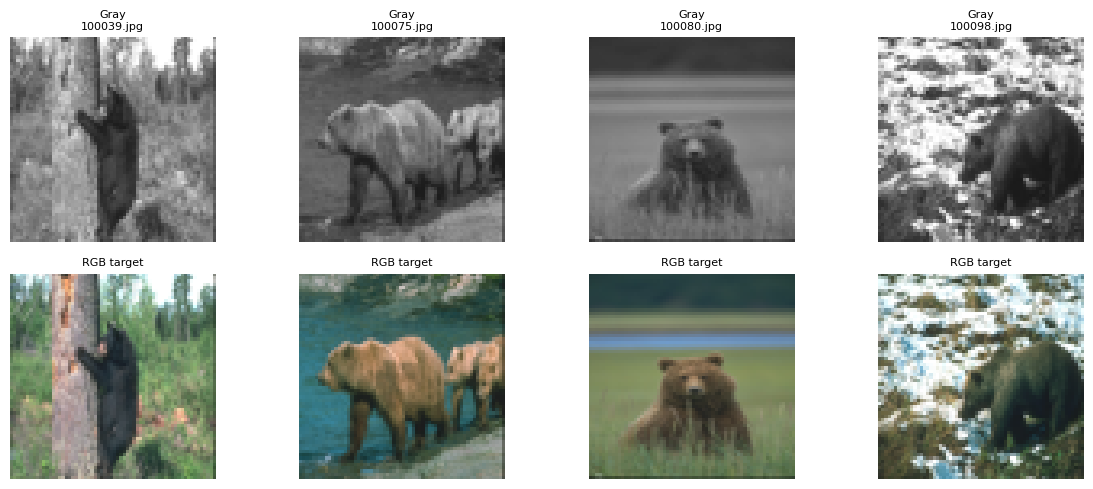

In [15]:
def show_preprocessing_examples(dataset, count=4):
    count = min(count, len(dataset))
    fig, axes = plt.subplots(2, count, figsize=(3 * count, 5))
    for idx in range(count):
        gray, rgb, name = dataset[idx]
        axes[0, idx].imshow(gray.squeeze(0), cmap="gray", vmin=0, vmax=1)
        axes[0, idx].set_title(f"Gray\n{name}", fontsize=8)
        axes[0, idx].axis("off")
        axes[1, idx].imshow(rgb.permute(1, 2, 0).numpy())
        axes[1, idx].set_title("RGB target", fontsize=8)
        axes[1, idx].axis("off")
    fig.tight_layout()
    if "get_ipython" in globals():
        plt.show()
    plt.close(fig)


show_preprocessing_examples(train_dataset, count=4)


## Convolutional Autoencoder


In [16]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.down = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            ConvBlock(out_channels, out_channels),
        )

    def forward(self, x):
        return self.down(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        self.fuse = ConvBlock(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.fuse(x)


class ColorizationAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = DownBlock(1, 32)      # 64 -> 32
        self.down2 = DownBlock(32, 64)     # 32 -> 16
        self.down3 = DownBlock(64, 128)    # 16 -> 8
        self.bottleneck = DownBlock(128, 256)  # 8 -> 4

        self.up3 = UpBlock(256, 128, 128)  # 4 -> 8
        self.up2 = UpBlock(128, 64, 64)    # 8 -> 16
        self.up1 = UpBlock(64, 32, 32)     # 16 -> 32
        self.final_up = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )
        self.final_fuse = ConvBlock(17, 16)  # Concatenate full-resolution grayscale input.
        self.output = nn.Sequential(
            nn.Conv2d(16, 3, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, gray):
        e1 = self.down1(gray)
        e2 = self.down2(e1)
        e3 = self.down3(e2)
        z = self.bottleneck(e3)
        d3 = self.up3(z, e3)
        d2 = self.up2(d3, e2)
        d1 = self.up1(d2, e1)
        d0 = self.final_up(d1)
        d0 = self.final_fuse(torch.cat([d0, gray], dim=1))
        return self.output(d0)


autoencoder = ColorizationAutoencoder().to(DEVICE)
ae_loss_fn = nn.MSELoss()
ae_optimizer = torch.optim.Adam(autoencoder.parameters(), lr=AE_LR, weight_decay=1e-5)
ae_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(ae_optimizer, mode="min", factor=0.5, patience=4)
BEST_AE_PATH = CHECKPOINTS_DIR / "colorization_autoencoder_best.pt"

print(autoencoder)


ColorizationAutoencoder(
  (down1): DownBlock(
    (down): Sequential(
      (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): ConvBlock(
        (block): Sequential(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU(inplace=True)
        )
      )
    )
  )
  (down2): DownBlock(
    (down): Sequential(
      (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inp

In [17]:
def run_autoencoder_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_samples = 0
    for gray, rgb, _ in loader:
        gray = gray.to(DEVICE)
        rgb = rgb.to(DEVICE)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
        pred = model(gray)
        loss = ae_loss_fn(pred, rgb)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * gray.size(0)
        total_samples += gray.size(0)
    return total_loss / total_samples


train_losses = []
val_losses = []
best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0
start_time = time.time()

for epoch in range(1, AE_EPOCHS + 1):
    train_loss = run_autoencoder_epoch(autoencoder, train_loader, ae_optimizer)
    with torch.no_grad():
        val_loss = run_autoencoder_epoch(autoencoder, val_loader, optimizer=None)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    previous_best = best_val_loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(autoencoder.state_dict(), BEST_AE_PATH)
    if val_loss < previous_best - AE_MIN_DELTA:
        patience_counter = 0
    else:
        patience_counter += 1
    ae_scheduler.step(val_loss)
    current_lr = ae_optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:02d}/{AE_EPOCHS} | train MSE: {train_loss:.5f} | "
        f"val MSE: {val_loss:.5f} | lr: {current_lr:.2e} | patience: {patience_counter}/{AE_PATIENCE}"
    )
    if patience_counter >= AE_PATIENCE:
        print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
        break

ae_elapsed = time.time() - start_time
print(f"Best validation MSE: {best_val_loss:.5f} at epoch {best_epoch}")
print(f"Saved best model to {BEST_AE_PATH}")
print(f"Autoencoder training completed in {ae_elapsed:.1f} seconds.")


Epoch 01/50 | train MSE: 0.05389 | val MSE: 0.05668 | lr: 1.00e-03 | patience: 0/10
Epoch 02/50 | train MSE: 0.02144 | val MSE: 0.02361 | lr: 1.00e-03 | patience: 0/10
Epoch 03/50 | train MSE: 0.01401 | val MSE: 0.01429 | lr: 1.00e-03 | patience: 0/10
Epoch 04/50 | train MSE: 0.01222 | val MSE: 0.01149 | lr: 1.00e-03 | patience: 0/10
Epoch 05/50 | train MSE: 0.01137 | val MSE: 0.01070 | lr: 1.00e-03 | patience: 0/10
Epoch 06/50 | train MSE: 0.01053 | val MSE: 0.01162 | lr: 1.00e-03 | patience: 1/10
Epoch 07/50 | train MSE: 0.01019 | val MSE: 0.01109 | lr: 1.00e-03 | patience: 2/10
Epoch 08/50 | train MSE: 0.00974 | val MSE: 0.01069 | lr: 1.00e-03 | patience: 3/10
Epoch 09/50 | train MSE: 0.00973 | val MSE: 0.00979 | lr: 1.00e-03 | patience: 0/10
Epoch 10/50 | train MSE: 0.00944 | val MSE: 0.01122 | lr: 1.00e-03 | patience: 1/10
Epoch 11/50 | train MSE: 0.00882 | val MSE: 0.00918 | lr: 1.00e-03 | patience: 0/10
Epoch 12/50 | train MSE: 0.00860 | val MSE: 0.00870 | lr: 1.00e-03 | patienc

## Colorization Results and Metrics


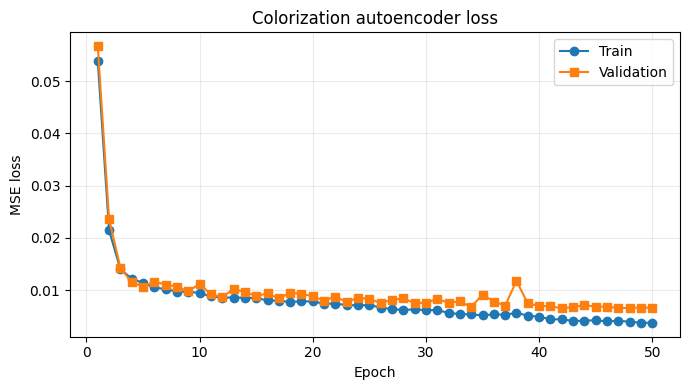

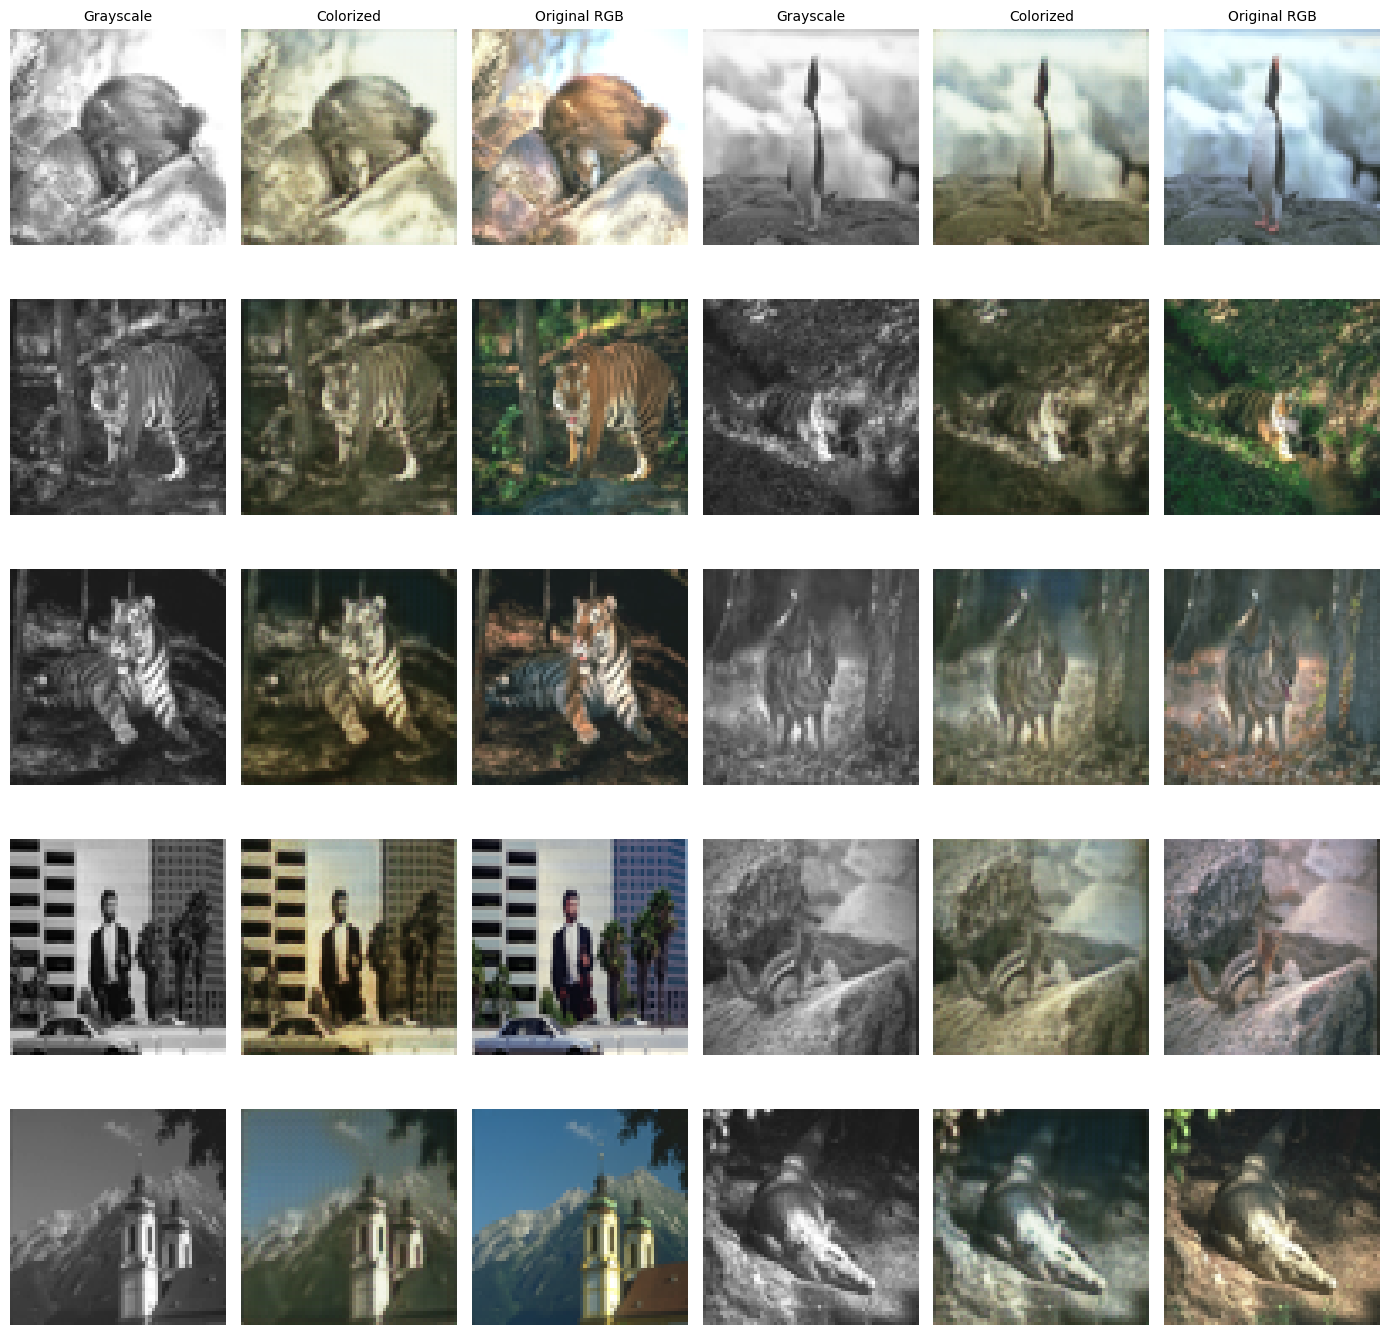

     image     MSE  PSNR   SSIM
105025.jpg 0.00327 24.85 0.9331
106024.jpg 0.00500 23.01 0.9444
108005.jpg 0.00192 27.16 0.9253
108070.jpg 0.00177 27.53 0.9160
108082.jpg 0.00170 27.68 0.9441
109053.jpg 0.00120 29.22 0.9241
119082.jpg 0.00748 21.26 0.9182
123074.jpg 0.00242 26.16 0.9544
126007.jpg 0.00495 23.05 0.8742
130026.jpg 0.00263 25.80 0.9427
   Average 0.00324 25.57 0.9276
Saved autoencoder loss curve to figures\autoencoder_loss_curve.png
Saved test visualization to figures\autoencoder_test_results.png


In [18]:
def save_ae_loss_curve(train_losses, val_losses, path):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="Train")
    ax.plot(range(1, len(val_losses) + 1), val_losses, marker="s", label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss")
    ax.set_title("Colorization autoencoder loss")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    if "get_ipython" in globals():
        plt.show()
    plt.close(fig)


def tensor_to_rgb_array(tensor):
    return tensor.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()


def tensor_to_gray_array(tensor):
    return tensor.detach().cpu().clamp(0, 1).squeeze(0).numpy()


def psnr_from_mse(mse, max_value=1.0):
    if mse <= 1e-12:
        return float("inf")
    return 20.0 * math.log10(max_value) - 10.0 * math.log10(mse)


def evaluate_autoencoder(model, loader, output_path):
    model.load_state_dict(torch.load(BEST_AE_PATH, map_location=DEVICE))
    model.eval()
    rows = []
    visual_rows = []

    with torch.no_grad():
        for gray, rgb, names in loader:
            gray = gray.to(DEVICE)
            rgb = rgb.to(DEVICE)
            pred = model(gray).clamp(0, 1)

            pred_np = tensor_to_rgb_array(pred[0])
            rgb_np = tensor_to_rgb_array(rgb[0])
            gray_np = tensor_to_gray_array(gray[0])

            mse = float(np.mean((pred_np - rgb_np) ** 2))
            psnr = float(psnr_from_mse(mse))
            ssim = float(structural_similarity(rgb_np, pred_np, channel_axis=-1, data_range=1.0))

            rows.append({"image": names[0], "MSE": mse, "PSNR": psnr, "SSIM": ssim})
            visual_rows.append((gray_np, pred_np, rgb_np, names[0]))

    cases_per_row = 2
    rows_needed = int(math.ceil(len(visual_rows) / cases_per_row))
    fig, axes = plt.subplots(rows_needed, 3 * cases_per_row, figsize=(14, 2.8 * rows_needed))
    axes = np.array(axes).reshape(rows_needed, 3 * cases_per_row)
    column_titles = ["Grayscale", "Colorized", "Original RGB"] * cases_per_row
    for col, title in enumerate(column_titles):
        axes[0, col].set_title(title, fontsize=10)

    for idx, (gray_np, pred_np, rgb_np, name) in enumerate(visual_rows):
        row_idx = idx // cases_per_row
        group_offset = (idx % cases_per_row) * 3
        image_triplet = [gray_np, pred_np, rgb_np]
        for local_col, image_array in enumerate(image_triplet):
            ax = axes[row_idx, group_offset + local_col]
            if local_col == 0:
                ax.imshow(image_array, cmap="gray", vmin=0, vmax=1)
                ax.set_ylabel(name, fontsize=8)
            else:
                ax.imshow(image_array)
            ax.axis("off")

    for idx in range(len(visual_rows), rows_needed * cases_per_row):
        row_idx = idx // cases_per_row
        group_offset = (idx % cases_per_row) * 3
        for local_col in range(3):
            axes[row_idx, group_offset + local_col].axis("off")
    fig.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    if "get_ipython" in globals():
        plt.show()
    plt.close(fig)

    return pd.DataFrame(rows)


ae_loss_curve_path = FIGURES_DIR / "autoencoder_loss_curve.png"
ae_test_results_path = FIGURES_DIR / "autoencoder_test_results.png"
save_ae_loss_curve(train_losses, val_losses, ae_loss_curve_path)
metrics_df = evaluate_autoencoder(autoencoder, test_loader, ae_test_results_path)

avg_row = {
    "image": "Average",
    "MSE": metrics_df["MSE"].mean(),
    "PSNR": metrics_df["PSNR"].mean(),
    "SSIM": metrics_df["SSIM"].mean(),
}
display_df = pd.concat([metrics_df, pd.DataFrame([avg_row])], ignore_index=True)
print(display_df.to_string(index=False, formatters={
    "MSE": "{:.5f}".format,
    "PSNR": "{:.2f}".format,
    "SSIM": "{:.4f}".format,
}))

print(f"Saved autoencoder loss curve to {ae_loss_curve_path}")
print(f"Saved test visualization to {ae_test_results_path}")


## Short Notes

Pixel-wise MSE encourages spatially aligned reconstructions but often produces muted colors. Images whose likely colors are common in the training set are easier; scenes with unusual lighting or ambiguous object colors are harder.


# Bonus: Adversarial Autoencoder for Latent Space Learning

The AAE reconstructs RGB images while adversarially regularizing the latent vectors to match a standard Gaussian prior.


In [19]:
all_rgb_files = train_files + val_files
rgb_train_dataset = RGBImageDataset(all_rgb_files)
rgb_test_dataset = RGBImageDataset(test_files)
rgb_train_loader = DataLoader(rgb_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=torch.Generator().manual_seed(SEED))
rgb_eval_loader = DataLoader(rgb_train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
rgb_test_loader = DataLoader(rgb_test_dataset, batch_size=2, shuffle=False, num_workers=0)


class RGBEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        self.fc = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        features = self.conv(x).view(x.size(0), -1)
        return self.fc(features)


class RGBDecoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.fc(z).view(z.size(0), 256, 4, 4)
        return self.deconv(x)


class LatentDiscriminator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(64, 1),
        )

    def forward(self, z):
        return self.net(z).squeeze(1)


# Reset before the bonus model so AAE results do not depend on earlier training cells.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

aae_encoder = RGBEncoder(LATENT_DIM).to(DEVICE)
aae_decoder = RGBDecoder(LATENT_DIM).to(DEVICE)
latent_discriminator = LatentDiscriminator(LATENT_DIM).to(DEVICE)

recon_loss_fn = nn.MSELoss()
adv_loss_fn = nn.BCEWithLogitsLoss()
ae_recon_optimizer = torch.optim.Adam(list(aae_encoder.parameters()) + list(aae_decoder.parameters()), lr=AAE_LR)
latent_disc_optimizer = torch.optim.Adam(latent_discriminator.parameters(), lr=AAE_ADV_LR)
encoder_adv_optimizer = torch.optim.Adam(aae_encoder.parameters(), lr=AAE_ADV_LR)


In [20]:
aae_recon_losses = []
aae_disc_losses = []
aae_adv_losses = []
start_time = time.time()

for epoch in range(1, AAE_EPOCHS + 1):
    aae_encoder.train()
    aae_decoder.train()
    latent_discriminator.train()
    recon_total = 0.0
    disc_total = 0.0
    adv_total = 0.0
    sample_total = 0

    for rgb, _ in rgb_train_loader:
        rgb = rgb.to(DEVICE)
        batch_size = rgb.size(0)
        real_targets = torch.ones(batch_size, device=DEVICE)
        fake_targets = torch.zeros(batch_size, device=DEVICE)

        ae_recon_optimizer.zero_grad(set_to_none=True)
        z_encoded = aae_encoder(rgb)
        reconstructed = aae_decoder(z_encoded)
        recon_loss = recon_loss_fn(reconstructed, rgb)
        recon_loss.backward()
        ae_recon_optimizer.step()

        latent_disc_optimizer.zero_grad(set_to_none=True)
        z_prior = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
        with torch.no_grad():
            z_fake = aae_encoder(rgb)
        real_logits = latent_discriminator(z_prior)
        fake_logits = latent_discriminator(z_fake)
        disc_loss = 0.5 * (adv_loss_fn(real_logits, real_targets) + adv_loss_fn(fake_logits, fake_targets))
        disc_loss.backward()
        latent_disc_optimizer.step()

        encoder_adv_optimizer.zero_grad(set_to_none=True)
        z_encoded = aae_encoder(rgb)
        fooled_logits = latent_discriminator(z_encoded)
        adv_loss = adv_loss_fn(fooled_logits, real_targets)
        adv_loss.backward()
        encoder_adv_optimizer.step()

        recon_total += recon_loss.item() * batch_size
        disc_total += disc_loss.item() * batch_size
        adv_total += adv_loss.item() * batch_size
        sample_total += batch_size

    aae_recon_losses.append(recon_total / sample_total)
    aae_disc_losses.append(disc_total / sample_total)
    aae_adv_losses.append(adv_total / sample_total)
    print(
        f"AAE epoch {epoch:02d}/{AAE_EPOCHS} | "
        f"recon: {aae_recon_losses[-1]:.5f} | "
        f"D: {aae_disc_losses[-1]:.4f} | "
        f"adv: {aae_adv_losses[-1]:.4f}"
    )

aae_elapsed = time.time() - start_time
print(f"AAE training completed in {aae_elapsed:.1f} seconds.")


AAE epoch 01/50 | recon: 0.05565 | D: 0.8412 | adv: 0.6309
AAE epoch 02/50 | recon: 0.03842 | D: 0.6209 | adv: 1.4803
AAE epoch 03/50 | recon: 0.03440 | D: 0.8116 | adv: 0.9745
AAE epoch 04/50 | recon: 0.03246 | D: 0.6685 | adv: 1.8046
AAE epoch 05/50 | recon: 0.03219 | D: 0.6884 | adv: 1.8925
AAE epoch 06/50 | recon: 0.03136 | D: 0.7382 | adv: 1.9971
AAE epoch 07/50 | recon: 0.03055 | D: 0.7690 | adv: 2.0599
AAE epoch 08/50 | recon: 0.03011 | D: 0.6026 | adv: 2.9331
AAE epoch 09/50 | recon: 0.02976 | D: 0.6691 | adv: 2.1580
AAE epoch 10/50 | recon: 0.02868 | D: 0.6847 | adv: 1.8200
AAE epoch 11/50 | recon: 0.02827 | D: 0.6663 | adv: 1.8082
AAE epoch 12/50 | recon: 0.02746 | D: 0.6259 | adv: 1.8216
AAE epoch 13/50 | recon: 0.02654 | D: 0.6158 | adv: 1.7377
AAE epoch 14/50 | recon: 0.02579 | D: 0.5856 | adv: 1.7581
AAE epoch 15/50 | recon: 0.02503 | D: 0.6057 | adv: 1.5269
AAE epoch 16/50 | recon: 0.02445 | D: 0.5915 | adv: 1.5406
AAE epoch 17/50 | recon: 0.02332 | D: 0.6134 | adv: 1.29

## Bonus Visualizations


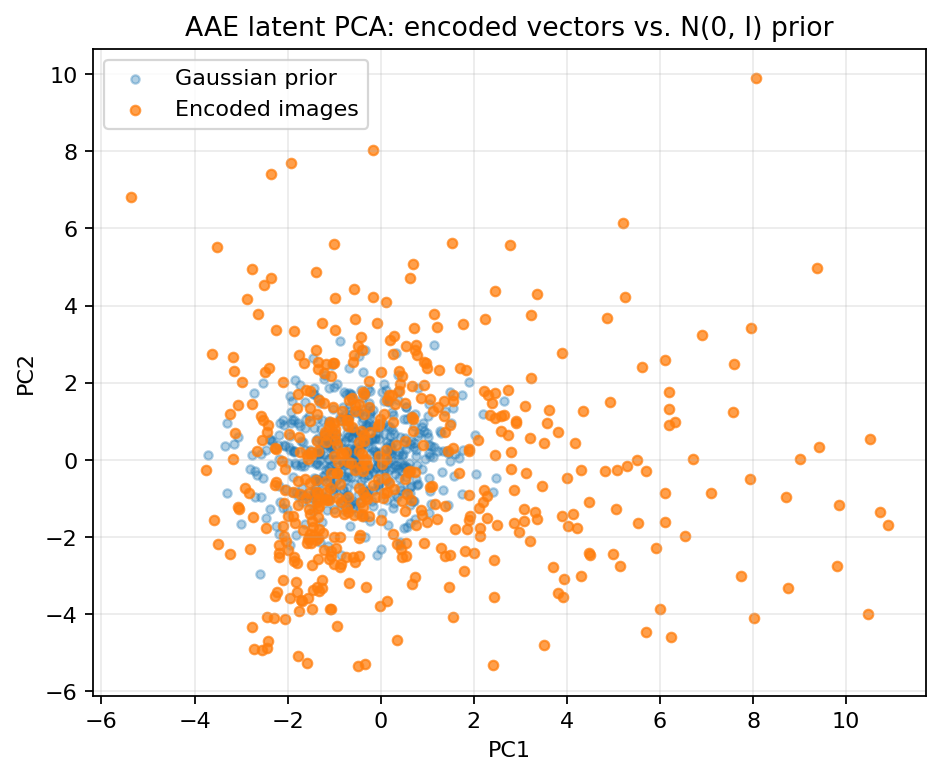

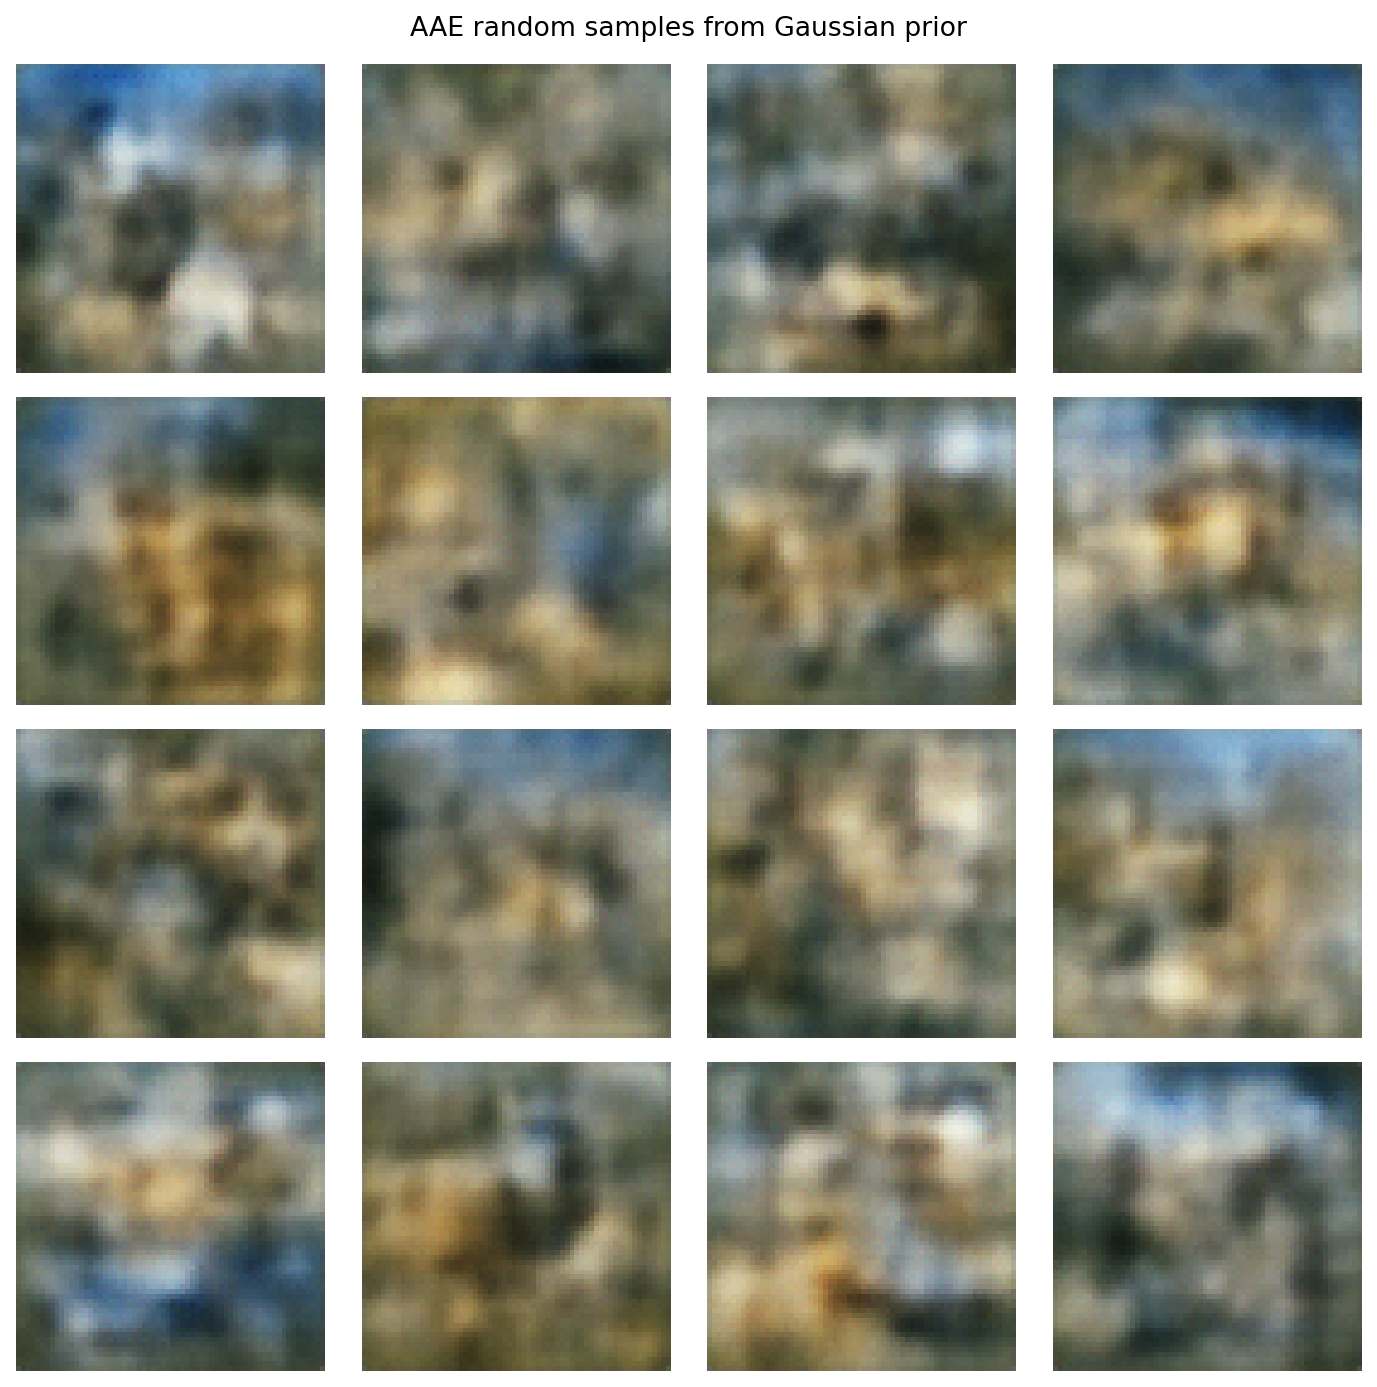

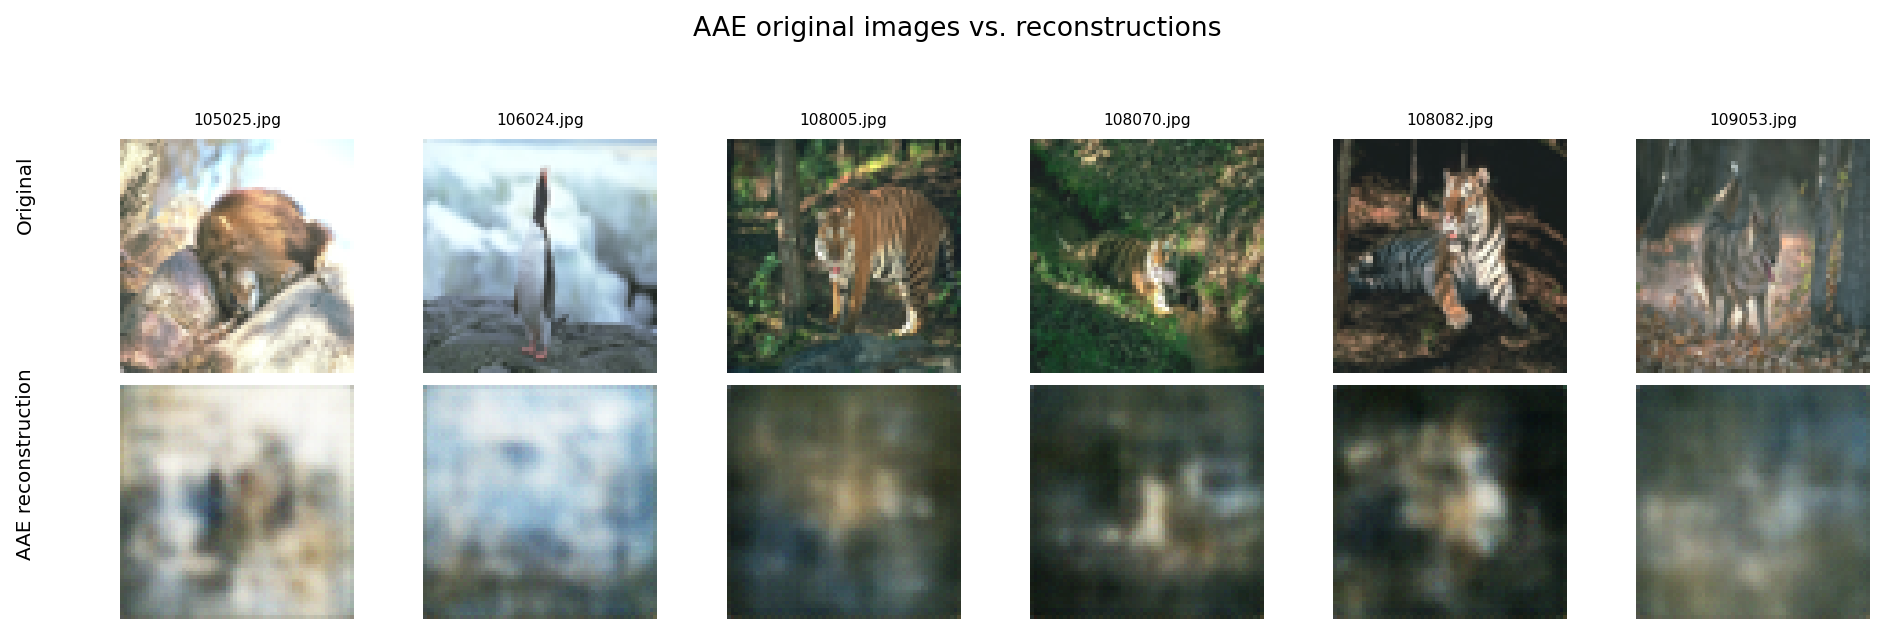

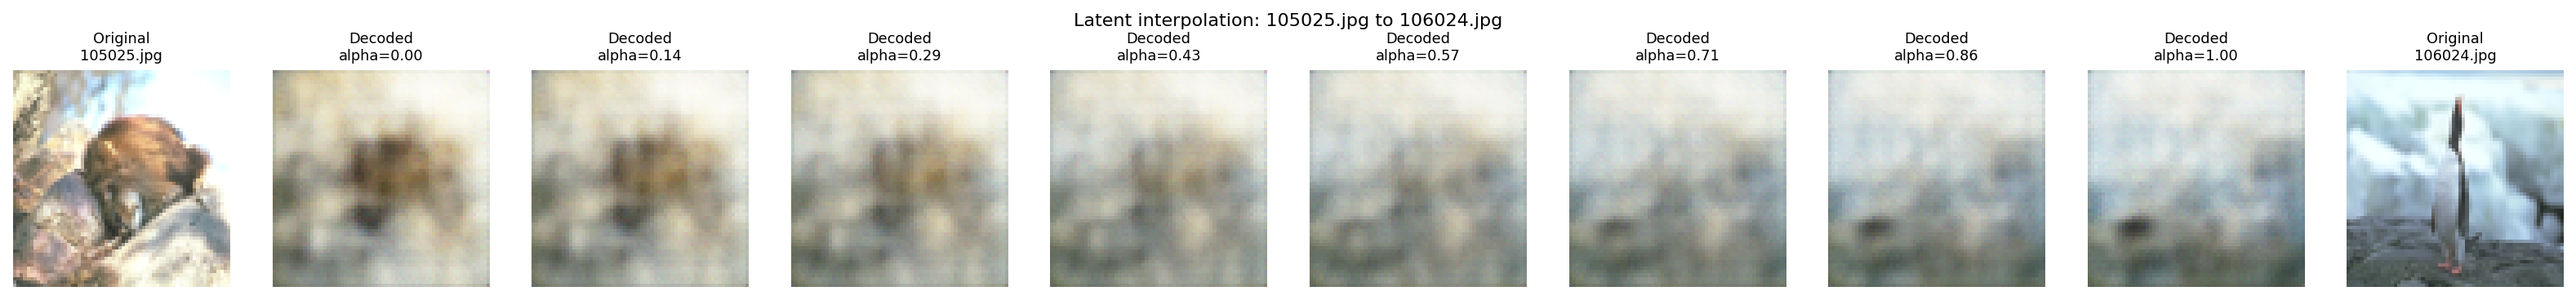

Saved latent PCA plot to figures\aae_latent_pca.png
Saved random prior samples to figures\aae_random_samples.png
Saved AAE reconstruction comparison to figures\aae_reconstructions.png
Saved latent interpolation to figures\aae_interpolation.png


In [21]:
def save_rgb_grid(tensors, path, nrow=4, title=None):
    images = tensors.detach().cpu().clamp(0, 1)
    count = images.size(0)
    ncol = nrow
    nrows = int(math.ceil(count / ncol))
    fig, axes = plt.subplots(nrows, ncol, figsize=(2.2 * ncol, 2.2 * nrows))
    axes = np.array(axes).reshape(nrows, ncol)
    for idx in range(nrows * ncol):
        ax = axes[idx // ncol, idx % ncol]
        if idx < count:
            ax.imshow(images[idx].permute(1, 2, 0).numpy())
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    if "get_ipython" in globals():
        plt.show()
    plt.close(fig)


def collect_latents(encoder, loader):
    encoder.eval()
    latents = []
    names = []
    with torch.no_grad():
        for rgb, batch_names in loader:
            z = encoder(rgb.to(DEVICE)).cpu().numpy()
            latents.append(z)
            names.extend(batch_names)
    return np.vstack(latents), names


def save_latent_pca(encoded_latents, path):
    prior = np.random.default_rng(SEED).standard_normal(encoded_latents.shape)
    combined = np.vstack([encoded_latents, prior])
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(combined)
    encoded_2d = reduced[: len(encoded_latents)]
    prior_2d = reduced[len(encoded_latents):]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(prior_2d[:, 0], prior_2d[:, 1], s=14, alpha=0.35, label="Gaussian prior")
    ax.scatter(encoded_2d[:, 0], encoded_2d[:, 1], s=18, alpha=0.75, label="Encoded images")
    ax.set_title("AAE latent PCA: encoded vectors vs. N(0, I) prior")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    if "get_ipython" in globals():
        plt.show()
    plt.close(fig)


def save_aae_reconstructions(encoder, decoder, loader, path, max_images=6):
    encoder.eval()
    decoder.eval()
    originals = []
    reconstructions = []
    names = []
    with torch.no_grad():
        for rgb, batch_names in loader:
            rgb = rgb.to(DEVICE)
            reconstructed = decoder(encoder(rgb)).cpu().clamp(0, 1)
            originals.append(rgb.cpu().clamp(0, 1))
            reconstructions.append(reconstructed)
            names.extend(batch_names)
            if len(names) >= max_images:
                break

    originals = torch.cat(originals, dim=0)[:max_images]
    reconstructions = torch.cat(reconstructions, dim=0)[:max_images]
    names = names[:max_images]
    count = originals.size(0)

    fig, axes = plt.subplots(2, count, figsize=(2.0 * count, 4.0))
    axes = np.array(axes).reshape(2, count)
    for idx in range(count):
        axes[0, idx].imshow(originals[idx].permute(1, 2, 0).numpy())
        axes[0, idx].set_title(names[idx], fontsize=7)
        axes[1, idx].imshow(reconstructions[idx].permute(1, 2, 0).numpy())
        axes[0, idx].axis("off")
        axes[1, idx].axis("off")
    fig.text(0.01, 0.70, "Original", rotation=90, va="center", fontsize=9)
    fig.text(0.01, 0.28, "AAE reconstruction", rotation=90, va="center", fontsize=9)
    fig.suptitle("AAE original images vs. reconstructions", fontsize=12)
    fig.tight_layout(rect=(0.04, 0, 1, 0.94))
    fig.savefig(path, dpi=160, bbox_inches="tight")
    if "get_ipython" in globals():
        plt.show()
    plt.close(fig)


def save_interpolation(encoder, decoder, loader, path, steps=8):
    encoder.eval()
    decoder.eval()
    rgb, names = next(iter(loader))
    rgb = rgb.to(DEVICE)
    if rgb.size(0) < 2:
        raise ValueError("Need at least two test images for interpolation.")
    with torch.no_grad():
        z = encoder(rgb[:2])
        alphas = torch.linspace(0, 1, steps, device=DEVICE).view(-1, 1)
        z_interp = (1 - alphas) * z[0:1] + alphas * z[1:2]
        decoded = decoder(z_interp).cpu().clamp(0, 1)
    originals = rgb[:2].detach().cpu().clamp(0, 1)

    fig, axes = plt.subplots(1, steps + 2, figsize=(2.0 * (steps + 2), 2.3))
    axes = np.array(axes).reshape(steps + 2)
    axes[0].imshow(originals[0].permute(1, 2, 0).numpy())
    axes[0].axis("off")
    axes[0].set_title(f"Original\n{names[0]}", fontsize=8)
    for idx in range(steps):
        ax = axes[idx + 1]
        alpha_value = idx / (steps - 1) if steps > 1 else 0.0
        ax.imshow(decoded[idx].permute(1, 2, 0).numpy())
        ax.axis("off")
        ax.set_title(f"Decoded\nalpha={alpha_value:.2f}", fontsize=8)
    axes[-1].imshow(originals[1].permute(1, 2, 0).numpy())
    axes[-1].axis("off")
    axes[-1].set_title(f"Original\n{names[1]}", fontsize=8)
    fig.suptitle(f"Latent interpolation: {names[0]} to {names[1]}", fontsize=10)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    if "get_ipython" in globals():
        plt.show()
    plt.close(fig)


aae_encoder.eval()
aae_decoder.eval()
encoded_latents, latent_names = collect_latents(aae_encoder, rgb_eval_loader)

latent_pca_path = FIGURES_DIR / "aae_latent_pca.png"
random_samples_path = FIGURES_DIR / "aae_random_samples.png"
reconstruction_path = FIGURES_DIR / "aae_reconstructions.png"
interpolation_path = FIGURES_DIR / "aae_interpolation.png"

save_latent_pca(encoded_latents, latent_pca_path)
with torch.no_grad():
    z_random = torch.randn(16, LATENT_DIM, device=DEVICE)
    random_samples = aae_decoder(z_random)
save_rgb_grid(random_samples, random_samples_path, nrow=4, title="AAE random samples from Gaussian prior")
save_aae_reconstructions(aae_encoder, aae_decoder, rgb_test_loader, reconstruction_path, max_images=6)
save_interpolation(aae_encoder, aae_decoder, rgb_test_loader, interpolation_path, steps=8)

print(f"Saved latent PCA plot to {latent_pca_path}")
print(f"Saved random prior samples to {random_samples_path}")
print(f"Saved AAE reconstruction comparison to {reconstruction_path}")
print(f"Saved latent interpolation to {interpolation_path}")


In [22]:
TASK2_SUMMARY = {
    "dataset_root": str(ae_root),
    "original_train_count": int(len(train_files_all)),
    "train_count": int(len(train_files)),
    "val_count": int(len(val_files)),
    "test_count": int(len(test_files)),
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "ae_epochs": AE_EPOCHS,
    "ae_learning_rate": AE_LR,
    "ae_loss": "MSELoss",
    "ae_optimizer": "Adam with weight_decay=1e-5",
    "ae_scheduler": "ReduceLROnPlateau(factor=0.5, patience=4)",
    "ae_architecture": "U-Net-style convolutional autoencoder with skip connections",
    "ae_patience": AE_PATIENCE,
    "ae_min_delta": AE_MIN_DELTA,
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val_loss),
    "train_losses": [float(x) for x in train_losses],
    "val_losses": [float(x) for x in val_losses],
    "test_metrics": [
        {
            "image": str(row["image"]),
            "MSE": float(row["MSE"]),
            "PSNR": float(row["PSNR"]),
            "SSIM": float(row["SSIM"]),
        }
        for _, row in metrics_df.iterrows()
    ],
    "test_metrics_average": {
        "MSE": float(avg_row["MSE"]),
        "PSNR": float(avg_row["PSNR"]),
        "SSIM": float(avg_row["SSIM"]),
    },
    "best_model_path": str(BEST_AE_PATH),
    "figures": {
        "loss_curve": str(ae_loss_curve_path),
        "test_results": str(ae_test_results_path),
    },
    "aae": {
        "latent_dim": LATENT_DIM,
        "epochs": AAE_EPOCHS,
        "learning_rate": AAE_LR,
        "adv_learning_rate": AAE_ADV_LR,
        "prior": "standard Gaussian N(0, I)",
        "reconstruction_losses": [float(x) for x in aae_recon_losses],
        "discriminator_losses": [float(x) for x in aae_disc_losses],
        "adversarial_encoder_losses": [float(x) for x in aae_adv_losses],
        "elapsed_seconds": float(aae_elapsed),
        "figures": {
            "latent_pca": str(latent_pca_path),
            "random_samples": str(random_samples_path),
            "reconstructions": str(reconstruction_path),
            "interpolation": str(interpolation_path),
        },
    },
}
TASK2_SUMMARY


{'dataset_root': 'data\\AE DATA',
 'original_train_count': 490,
 'train_count': 441,
 'val_count': 49,
 'test_count': 10,
 'image_size': 64,
 'batch_size': 32,
 'ae_epochs': 50,
 'ae_learning_rate': 0.001,
 'ae_loss': 'MSELoss',
 'ae_optimizer': 'Adam with weight_decay=1e-5',
 'ae_scheduler': 'ReduceLROnPlateau(factor=0.5, patience=4)',
 'ae_architecture': 'U-Net-style convolutional autoencoder with skip connections',
 'ae_patience': 10,
 'ae_min_delta': 0.0001,
 'best_epoch': 42,
 'best_val_loss': 0.006563476838019429,
 'train_losses': [0.05389492045623375,
  0.02144384920563287,
  0.014008910363527383,
  0.012223280184900138,
  0.011372220993903623,
  0.010527994830051518,
  0.01019195858135718,
  0.009739916169775181,
  0.009734881691246077,
  0.009436954691364111,
  0.00882249931612658,
  0.008601836959436502,
  0.00858919282999236,
  0.008578841188022879,
  0.008486907046431857,
  0.008056420074720906,
  0.007987159520784676,
  0.00775167169239448,
  0.007886254558098965,
  0.0078

## Bonus Short Notes

Adversarial latent regularization trains the encoder so its latent vectors resemble samples from the chosen prior, here a standard Gaussian. PCA gives a two-dimensional view of whether encoded vectors overlap the prior samples. Random decoding tests whether the decoder can turn prior samples into plausible images. The reconstruction comparison shows how much detail the AAE preserves from original test images, and the interpolation plot includes the original endpoint images so the decoded latent path can be compared against the inputs.
